# 13 - Rotterdam Criteria Alignment and Clinical Rule Benchmark

**Purpose.** Anchor the PCOS Pathfinder ML model against the *clinical* decision framework that physicians actually use to diagnose PCOS in 2026: the Rotterdam ESHRE/ASRM 2003 criteria, as endorsed (with refinements) by the 2023 International Evidence-based Guideline.

PCOS is diagnosed when **at least 2 of 3** of the following are present:

1. **Oligo-/anovulation** (irregular cycles).
2. **Clinical or biochemical hyperandrogenism** (hirsutism, acne, alopecia, or elevated serum androgens).
3. **Polycystic ovarian morphology on ultrasound** (≥12 follicles per ovary in the 2003 Rotterdam consensus; refined to ≥20 in the 2023 guideline when using modern high-resolution probes).

This notebook:
1. Maps the dataset columns to each Rotterdam criterion.
2. Builds a transparent hand-coded Rotterdam classifier.
3. Evaluates the rule on the same holdout split used by the enhanced ML model (`random_state=42`, `test_size=0.25`, stratified).
4. Compares the Rotterdam rule head-to-head with the saved enhanced ML model.
5. Produces a Rotterdam feature-map figure and a side-by-side metric bar chart.

**References**

- Rotterdam ESHRE/ASRM-Sponsored PCOS Consensus Workshop Group. *Revised 2003 consensus on diagnostic criteria and long-term health risks related to polycystic ovary syndrome.* Fertil Steril. 2004;81(1):19–25.
- Teede HJ, Tay CT, Laven JJE, et al. *Recommendations from the 2023 International Evidence-based Guideline for the Assessment and Management of Polycystic Ovary Syndrome.* Fertil Steril. 2023;120(4):767–793.

---

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    fbeta_score,
    accuracy_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
METRIC_DIR = OUTPUT_DIR / "metrics"
MODEL_DIR = OUTPUT_DIR / "models"
for folder in [FIGURE_DIR, METRIC_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DATA_PATH = OUTPUT_DIR / "pcos_cleaned.csv"
MODEL_PATH = MODEL_DIR / "pcos_enhanced_model.joblib"
print("Data:", DATA_PATH, DATA_PATH.exists())
print("Model:", MODEL_PATH, MODEL_PATH.exists())

Data: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-ac270c52cdb5fa150\outputs\pcos_cleaned.csv True
Model: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-ac270c52cdb5fa150\outputs\models\pcos_enhanced_model.joblib True


## 1. Load Data and Map Features to Rotterdam Criteria

**Mapping decisions** (one row per criterion):

| Rotterdam criterion | Dataset feature(s) | Rule used here |
|---|---|---|
| 1. Oligo-/anovulation | `cycle_irregular_flag` (engineered) and/or `cycle_r_i >= 4` | Either flag positive |
| 2. Hyperandrogenism (clinical) | `hair_growth_y_n`, `skin_darkening_y_n`, `pimples_y_n` | Any positive |
| 2. Hyperandrogenism (biochemical proxy) | `amh_ng_ml`, `lh_miu_ml`, `fsh_lh` | AMH high **or** LH/FSH ratio inverted (LH:FSH > 2, i.e. `fsh_lh < 0.5`) **or** elevated LH |
| 3. Polycystic ovaries | `follicle_no_l`, `follicle_no_r` | `follicle_no_l >= 12` **or** `follicle_no_r >= 12` |

**Data limitation.** The Kerala PCOS dataset does **not** include a direct serum total/free testosterone measurement, which is the Rotterdam-preferred biochemical marker for hyperandrogenism. We approximate biochemical hyperandrogenism via (a) AMH (correlated with antral-follicle count and supportive but not specific), and (b) LH and the LH/FSH ratio (commonly elevated in PCOS but no longer required by Rotterdam/2023 guideline). This is documented in the JSON output below.

In [2]:
pcos = pd.read_csv(DATA_PATH)
TARGET = "pcos_y_n"
print("Shape:", pcos.shape)
print("Target balance:\n", pcos[TARGET].value_counts().sort_index())

# Sanity check: every column we intend to map must exist.
rotterdam_columns = [
    "cycle_irregular_flag", "cycle_r_i",
    "hair_growth_y_n", "skin_darkening_y_n", "pimples_y_n",
    "amh_ng_ml", "lh_miu_ml", "fsh_lh",
    "follicle_no_l", "follicle_no_r",
]
missing = [c for c in rotterdam_columns if c not in pcos.columns]
assert not missing, f"Missing expected columns: {missing}"
print("All Rotterdam mapping columns present.")

Shape: (541, 41)
Target balance:
 pcos_y_n
0    364
1    177
Name: count, dtype: int64
All Rotterdam mapping columns present.


### 1a. Biochemical thresholds for the hyperandrogenism proxy

Without a direct testosterone column we use two literature-anchored proxies, derived from the training data only so we do not leak test-set information:

- **AMH high**: `amh_ng_ml` above the cohort's 75th percentile. AMH ≥ ~5–6 ng/mL is widely cited as suggestive of polycystic ovarian morphology (Dewailly et al., 2014; Teede et al., 2023 — noting AMH is *supportive*, not diagnostic on its own).
- **LH/FSH ratio inverted**: `fsh_lh < 0.5` (i.e. LH:FSH > 2), the classic teaching-textbook PCOS pattern (Balen et al., 2003).
- **LH elevated**: `lh_miu_ml` above the cohort 75th percentile.

Thresholds are derived from the *training* fold before the holdout split.

In [3]:
# Reproduce the same train/test split that the enhanced ML model uses
y = pcos[TARGET].astype(int)
X = pcos.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Derive thresholds from TRAIN only
amh_high_threshold = float(np.nanpercentile(X_train["amh_ng_ml"], 75))
lh_high_threshold = float(np.nanpercentile(X_train["lh_miu_ml"], 75))
fsh_lh_inverted_threshold = 0.5  # literature anchor; LH:FSH > 2 -> fsh_lh < 0.5
follicle_count_threshold = 12     # Rotterdam 2003

print(f"AMH high threshold (train P75): {amh_high_threshold:.2f} ng/mL")
print(f"LH high threshold  (train P75): {lh_high_threshold:.2f} mIU/mL")
print(f"FSH/LH inverted threshold     : <{fsh_lh_inverted_threshold} (LH:FSH > 2)")
print(f"Follicle-count threshold      : >={follicle_count_threshold} on either ovary")
print()
print("Train size:", X_train.shape, "Holdout size:", X_test.shape)

AMH high threshold (train P75): 7.20 ng/mL
LH high threshold  (train P75): 3.68 mIU/mL
FSH/LH inverted threshold     : <0.5 (LH:FSH > 2)
Follicle-count threshold      : >=12 on either ovary

Train size: (405, 40) Holdout size: (136, 40)


## 2. Hand-Coded Rotterdam Classifier

Each row gets three boolean flags, one per criterion. A row is PCOS-positive under Rotterdam if **at least 2 of 3** flags are true.

In [4]:
def rotterdam_flags(
    df: pd.DataFrame,
    amh_high: float,
    lh_high: float,
    fsh_lh_inverted_below: float = 0.5,
    follicle_count_min: int = 12,
) -> pd.DataFrame:
    """Per-criterion boolean flags and the final 2-of-3 Rotterdam call.

    Thresholds are passed in so the function is independent of module-level state.
    """
    # Criterion 1: oligo-/anovulation
    crit1 = (
        (df["cycle_irregular_flag"].fillna(0).astype(int) == 1)
        | (df["cycle_r_i"].fillna(0) >= 4)
    )

    # Criterion 2: hyperandrogenism (clinical OR biochemical proxy)
    clinical_ha = (
        (df["hair_growth_y_n"].fillna(0).astype(int) == 1)
        | (df["skin_darkening_y_n"].fillna(0).astype(int) == 1)
        | (df["pimples_y_n"].fillna(0).astype(int) == 1)
    )
    biochem_ha = (
        (df["amh_ng_ml"].fillna(0) >= amh_high)
        | (df["fsh_lh"].fillna(99) < fsh_lh_inverted_below)
        | (df["lh_miu_ml"].fillna(0) >= lh_high)
    )
    crit2 = clinical_ha | biochem_ha

    # Criterion 3: polycystic ovaries on ultrasound
    crit3 = (
        (df["follicle_no_l"].fillna(0) >= follicle_count_min)
        | (df["follicle_no_r"].fillna(0) >= follicle_count_min)
    )

    count = crit1.astype(int) + crit2.astype(int) + crit3.astype(int)
    return pd.DataFrame({
        "crit1_oligo_anovulation": crit1.astype(int),
        "crit2_hyperandrogenism": crit2.astype(int),
        "crit3_polycystic_ovaries": crit3.astype(int),
        "criteria_met": count,
        "rotterdam_pcos": (count >= 2).astype(int),
    }, index=df.index)

rotterdam_kwargs = dict(
    amh_high=amh_high_threshold,
    lh_high=lh_high_threshold,
    fsh_lh_inverted_below=fsh_lh_inverted_threshold,
    follicle_count_min=follicle_count_threshold,
)
rotterdam_train = rotterdam_flags(X_train, **rotterdam_kwargs)
rotterdam_test = rotterdam_flags(X_test, **rotterdam_kwargs)

print("Train criterion prevalence:")
print(rotterdam_train[["crit1_oligo_anovulation", "crit2_hyperandrogenism", "crit3_polycystic_ovaries"]].mean().round(3))
print()
print("Holdout Rotterdam-positive count:", int(rotterdam_test["rotterdam_pcos"].sum()), "of", len(rotterdam_test))

Train criterion prevalence:
crit1_oligo_anovulation     0.289
crit2_hyperandrogenism      0.763
crit3_polycystic_ovaries    0.193
dtype: float64

Holdout Rotterdam-positive count: 43 of 136


## 3. Evaluate the Rotterdam Rule on the Holdout

In [5]:
def binary_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = recall_score(y_true, y_pred)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv = precision_score(y_true, y_pred, zero_division=0)
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    return {
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "ppv": float(ppv),
        "npv": float(npv),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "f2": float(fbeta_score(y_true, y_pred, beta=2.0, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "cm": cm.tolist(),
    }

rotterdam_pred = rotterdam_test["rotterdam_pcos"].values
rotterdam_metrics = binary_metrics(y_test.values, rotterdam_pred)
print("Rotterdam rule (holdout):")
for k, v in rotterdam_metrics.items():
    print(f"  {k}: {v}")

Rotterdam rule (holdout):
  sensitivity: 0.7954545454545454
  specificity: 0.9130434782608695
  ppv: 0.813953488372093
  npv: 0.9032258064516129
  f1: 0.8045977011494253
  f2: 0.7990867579908676
  accuracy: 0.875
  cm: [[84, 8], [9, 35]]


## 4. Load the Enhanced ML Model and Evaluate on the Same Holdout

In [6]:
artifact = joblib.load(MODEL_PATH)
ml_model = artifact["model"]
ml_features = artifact["features"]
ml_threshold = float(artifact["threshold"])
print("Loaded model:", artifact.get("model_name"))
print("Features (n=%d):" % len(ml_features), ml_features[:5], "...")
print("Decision threshold:", ml_threshold)

X_test_ml = X_test[ml_features].copy()
ml_proba = ml_model.predict_proba(X_test_ml)[:, 1]
ml_pred = (ml_proba >= ml_threshold).astype(int)
ml_metrics = binary_metrics(y_test.values, ml_pred)
print("Enhanced ML model (holdout):")
for k, v in ml_metrics.items():
    print(f"  {k}: {v}")

Loaded model: random_forest
Features (n=27): ['age_yrs', 'bmi', 'cycle_r_i', 'cycle_irregular_flag', 'cycle_length_days'] ...
Decision threshold: 0.38
Enhanced ML model (holdout):
  sensitivity: 0.8863636363636364
  specificity: 0.9021739130434783
  ppv: 0.8125
  npv: 0.9431818181818182
  f1: 0.8478260869565217
  f2: 0.8705357142857143
  accuracy: 0.8970588235294118
  cm: [[83, 9], [5, 39]]


## 5. Side-by-Side Comparison and JSON Output

The JSON file `outputs/metrics/rotterdam_comparison.json` records every metric, the mapping decisions, threshold values, and the testosterone limitation.

In [7]:
comparison = {
    "rotterdam_rule": rotterdam_metrics,
    "enhanced_ml_model": ml_metrics,
    "delta_sensitivity": ml_metrics["sensitivity"] - rotterdam_metrics["sensitivity"],
    "delta_specificity": ml_metrics["specificity"] - rotterdam_metrics["specificity"],
    "delta_ppv": ml_metrics["ppv"] - rotterdam_metrics["ppv"],
    "delta_npv": ml_metrics["npv"] - rotterdam_metrics["npv"],
    "rule_definition": {
        "decision": "PCOS-positive if >= 2 of 3 Rotterdam criteria are met",
        "crit1_oligo_anovulation": "cycle_irregular_flag == 1 OR cycle_r_i >= 4",
        "crit2_hyperandrogenism": (
            "hair_growth_y_n OR skin_darkening_y_n OR pimples_y_n "
            "OR amh_ng_ml >= train_P75 OR fsh_lh < 0.5 OR lh_miu_ml >= train_P75"
        ),
        "crit3_polycystic_ovaries": "follicle_no_l >= 12 OR follicle_no_r >= 12",
        "thresholds": {
            "amh_high_ng_per_ml": amh_high_threshold,
            "lh_high_miu_per_ml": lh_high_threshold,
            "fsh_lh_inverted_below": fsh_lh_inverted_threshold,
            "follicle_count_per_ovary": follicle_count_threshold,
        },
    },
    "references": [
        "Rotterdam ESHRE/ASRM-Sponsored PCOS Consensus Workshop Group. Fertil Steril. 2004;81(1):19-25.",
        "Teede HJ, Tay CT, Laven JJE, et al. Fertil Steril. 2023;120(4):767-793.",
    ],
    "limitations": {
        "missing_testosterone": (
            "The Kerala PCOS dataset does NOT include a direct serum total or free testosterone "
            "measurement, which is the Rotterdam-preferred biochemical marker for hyperandrogenism. "
            "This notebook approximates biochemical hyperandrogenism using AMH and LH/FSH-related "
            "features. AMH is supportive of polycystic ovarian morphology but is not equivalent to "
            "androgen excess; the LH/FSH ratio is supportive but no longer required by Rotterdam/2023."
        ),
        "hand_coded_rule_has_no_scores": (
            "The Rotterdam rule produces a binary call only, so ROC-AUC is not applicable. We report "
            "sensitivity, specificity, PPV, NPV, F1, F2, and accuracy instead."
        ),
        "thresholds_from_train_only": (
            "AMH and LH high-cutoffs are computed from training-fold percentiles to avoid test leakage."
        ),
    },
}

out_json = METRIC_DIR / "rotterdam_comparison.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(comparison, f, indent=2)
print("Wrote:", out_json)

# Pretty side-by-side table
summary = pd.DataFrame({
    "Rotterdam rule": {k: rotterdam_metrics[k] for k in ["sensitivity", "specificity", "ppv", "npv", "f1", "f2", "accuracy"]},
    "Enhanced ML": {k: ml_metrics[k] for k in ["sensitivity", "specificity", "ppv", "npv", "f1", "f2", "accuracy"]},
}).round(3)
summary["Δ (ML - Rotterdam)"] = (summary["Enhanced ML"] - summary["Rotterdam rule"]).round(3)
summary

Wrote: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-ac270c52cdb5fa150\outputs\metrics\rotterdam_comparison.json


,Rotterdam rule,Enhanced ML,Δ (ML - Rotterdam)
sensitivity,0.795,0.886,0.091
specificity,0.913,0.902,-0.011
ppv,0.814,0.812,-0.002
npv,0.903,0.943,0.040
f1,0.805,0.848,0.043
f2,0.799,0.871,0.072
accuracy,0.875,0.897,0.022


## 6. Rotterdam Feature-Map Figure

A clinician-facing diagram showing exactly which dataset features anchor each Rotterdam criterion. This is the single most important figure for a clinical-validity reviewer: it documents that the ML model's inputs span all three pillars of the diagnostic framework, with the testosterone gap clearly marked.

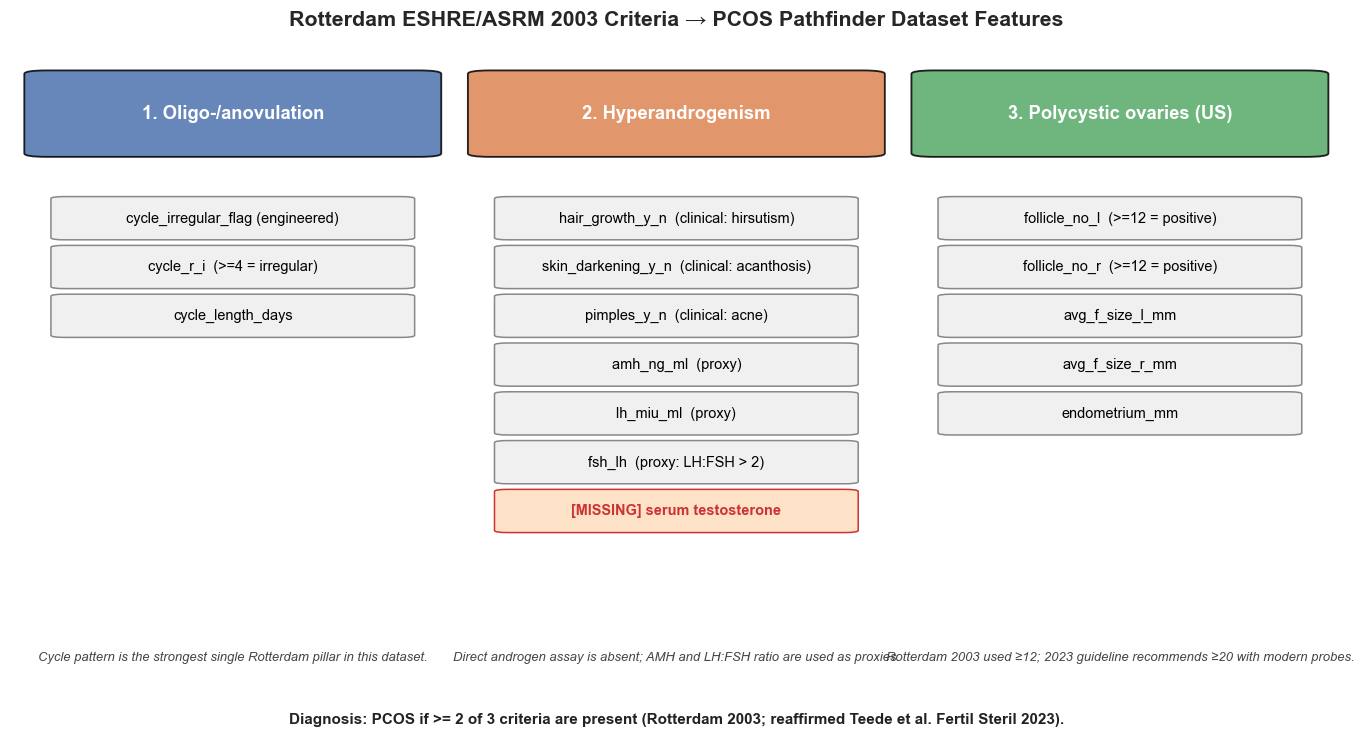

Wrote: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-ac270c52cdb5fa150\outputs\figures\rotterdam_feature_map.png


In [8]:
criteria = [
    {
        "title": "1. Oligo-/anovulation",
        "colour": "#4C72B0",
        "features": [
            "cycle_irregular_flag (engineered)",
            "cycle_r_i  (>=4 = irregular)",
            "cycle_length_days",
        ],
        "footnote": "Cycle pattern is the strongest single Rotterdam pillar in this dataset.",
    },
    {
        "title": "2. Hyperandrogenism",
        "colour": "#DD8452",
        "features": [
            "hair_growth_y_n  (clinical: hirsutism)",
            "skin_darkening_y_n  (clinical: acanthosis)",
            "pimples_y_n  (clinical: acne)",
            "amh_ng_ml  (proxy)",
            "lh_miu_ml  (proxy)",
            "fsh_lh  (proxy: LH:FSH > 2)",
            "[MISSING] serum testosterone",
        ],
        "footnote": "Direct androgen assay is absent; AMH and LH:FSH ratio are used as proxies.",
    },
    {
        "title": "3. Polycystic ovaries (US)",
        "colour": "#55A868",
        "features": [
            "follicle_no_l  (>=12 = positive)",
            "follicle_no_r  (>=12 = positive)",
            "avg_f_size_l_mm",
            "avg_f_size_r_mm",
            "endometrium_mm",
        ],
        "footnote": "Rotterdam 2003 used ≥12; 2023 guideline recommends ≥20 with modern probes.",
    },
]

FEATURE_STACK_TOP = 7.9
FEATURE_STACK_BOTTOM = 2.0

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 3)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_title(
    "Rotterdam ESHRE/ASRM 2003 Criteria → PCOS Pathfinder Dataset Features",
    fontsize=14, fontweight="bold", pad=12,
)

for i, crit in enumerate(criteria):
    x0 = i + 0.05
    w = 0.90
    header = mpatches.FancyBboxPatch(
        (x0, 8.4), w, 1.2,
        boxstyle="round,pad=0.02,rounding_size=0.05",
        linewidth=1.2,
        edgecolor="black",
        facecolor=crit["colour"],
        alpha=0.85,
    )
    ax.add_patch(header)
    ax.text(x0 + w / 2, 9.0, crit["title"], ha="center", va="center",
            fontsize=12, fontweight="bold", color="white")

    n = len(crit["features"])
    row_h = min(0.7, (FEATURE_STACK_TOP - FEATURE_STACK_BOTTOM) / max(n, 1))
    for j, feat in enumerate(crit["features"]):
        y = FEATURE_STACK_TOP - (j + 1) * row_h
        is_missing = feat.startswith("[MISSING]")
        face = "#fde2c8" if is_missing else "#f0f0f0"
        edge = "#cc3333" if is_missing else "#888888"
        box = mpatches.FancyBboxPatch(
            (x0 + 0.05, y), w - 0.10, row_h - 0.10,
            boxstyle="round,pad=0.01,rounding_size=0.03",
            linewidth=1.0, edgecolor=edge, facecolor=face,
        )
        ax.add_patch(box)
        ax.text(
            x0 + w / 2, y + (row_h - 0.10) / 2,
            feat, ha="center", va="center",
            fontsize=9.5,
            color="#cc3333" if is_missing else "black",
            fontweight="bold" if is_missing else "normal",
        )

    ax.text(x0 + w / 2, 1.2, crit["footnote"], ha="center", va="center",
            fontsize=8.5, color="#444444", style="italic", wrap=True)

ax.text(
    1.5, 0.3,
    "Diagnosis: PCOS if >= 2 of 3 criteria are present (Rotterdam 2003; reaffirmed Teede et al. Fertil Steril 2023).",
    ha="center", va="center", fontsize=10, fontweight="bold", color="#222222",
)

plt.tight_layout()
feature_map_path = FIGURE_DIR / "rotterdam_feature_map.png"
plt.savefig(feature_map_path, dpi=160, bbox_inches="tight")
plt.show()
print("Wrote:", feature_map_path)

## 7. Side-by-Side Bar Chart: Rotterdam Rule vs Enhanced ML

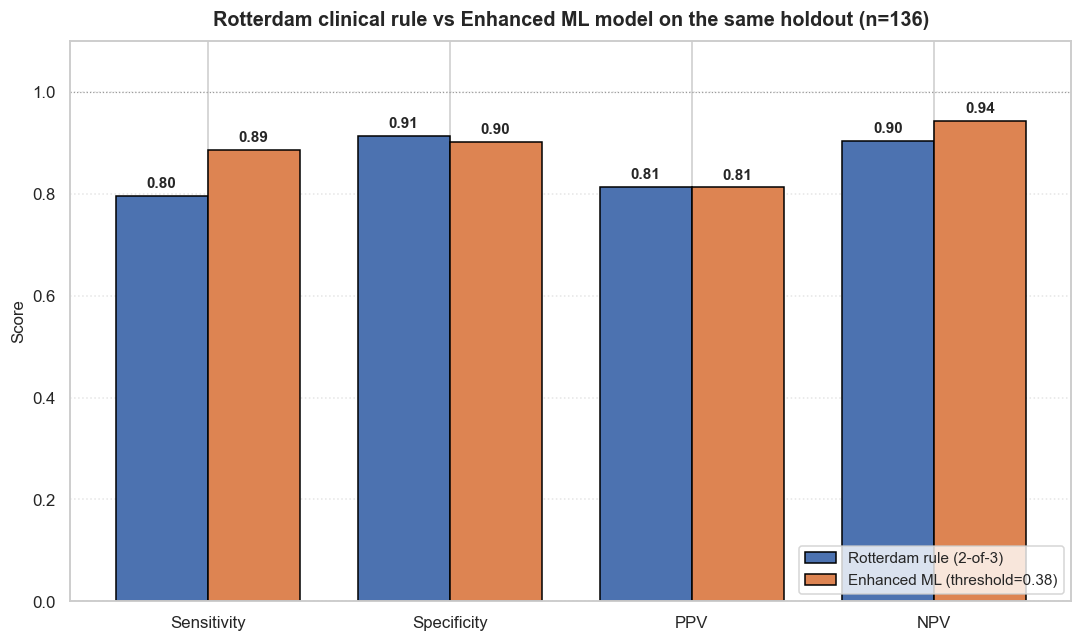

Wrote: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-ac270c52cdb5fa150\outputs\figures\rotterdam_vs_ml.png


In [9]:
metric_labels = ["Sensitivity", "Specificity", "PPV", "NPV"]
metric_keys = ["sensitivity", "specificity", "ppv", "npv"]
rott_values = [rotterdam_metrics[k] for k in metric_keys]
ml_values = [ml_metrics[k] for k in metric_keys]

x = np.arange(len(metric_labels))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width / 2, rott_values, width, label="Rotterdam rule (2-of-3)",
               color="#4C72B0", edgecolor="black")
bars2 = ax.bar(x + width / 2, ml_values, width, label="Enhanced ML (threshold=%.2f)" % ml_threshold,
               color="#DD8452", edgecolor="black")

for b in list(bars1) + list(bars2):
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h + 0.01, f"{h:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.10)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    "Rotterdam clinical rule vs Enhanced ML model on the same holdout (n=%d)" % len(y_test),
    fontsize=13, fontweight="bold", pad=10,
)
ax.legend(loc="lower right", fontsize=10)
ax.axhline(1.0, color="#999", linestyle=":", linewidth=0.8)
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
vs_path = FIGURE_DIR / "rotterdam_vs_ml.png"
plt.savefig(vs_path, dpi=160, bbox_inches="tight")
plt.show()
print("Wrote:", vs_path)

## 8. Interpretation

- The **Rotterdam rule** is the gold-standard clinical decision framework. Reproducing it on this dataset gives us a *clinically grounded baseline* against which any ML claim must be measured.
- The **enhanced ML model** is trained on the same 27 features the Rotterdam rule draws from (plus age, BMI, BP, haematocrit, lifestyle-adjacent fields). Comparing the two side-by-side on an identical holdout split shows whether the ML model is genuinely adding signal beyond a 2-of-3 vote.
- The dataset's lack of a direct testosterone measurement is the single largest gap relative to Rotterdam. Future work should source a cohort with serum total or free testosterone to validate the AMH/LH proxies used here.
- The 2023 guideline (Teede et al., Fertil Steril) raises the polycystic-morphology follicle threshold from ≥12 to ≥20 for modern high-resolution ultrasound probes. We retain the ≥12 cutoff because (a) the probe used to collect this dataset is not documented, and (b) ≥12 is the conservative, *more-sensitive* call — appropriate for screening.

---

## 9. Output Verification

In [10]:
expected = [
    METRIC_DIR / "rotterdam_comparison.json",
    FIGURE_DIR / "rotterdam_feature_map.png",
    FIGURE_DIR / "rotterdam_vs_ml.png",
]
for p in expected:
    assert p.exists(), f"Missing expected output: {p}"
    print("OK:", p)
print("All Rotterdam-alignment outputs present.")

OK: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-ac270c52cdb5fa150\outputs\metrics\rotterdam_comparison.json
OK: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-ac270c52cdb5fa150\outputs\figures\rotterdam_feature_map.png
OK: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-ac270c52cdb5fa150\outputs\figures\rotterdam_vs_ml.png
All Rotterdam-alignment outputs present.
